In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    "../data/cleaned_forecasting_data.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
import os
print(os.getcwd())

d:\MiniProject3_Medical Appointment(ML)\Notebook


In [4]:
df.shape

(109304, 36)

In [5]:
df.columns

Index(['no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received', 'place_encoded', 'specialty_enf',
       'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm'],
      dtype='object')

#create daily Traget(Y)
Daily appointment volume prediction

In [27]:
daily = df.resample('D').size().to_frame('y')

In [28]:
daily

,y
appointment_date_continuous,
2020-01-01,25
2020-01-02,32
2020-01-03,18
2020-01-04,16
2020-01-05,15
...,...
2021-05-08,1
2021-05-09,4
2021-05-10,3


| Level      | Data         | Meaning                   |
| ---------- | ------------ | ------------------------- |
| Raw        | (109304, 36) | patient-level dataset     |
| Aggregated | (498, 1)     | daily forecasting dataset |


In [29]:
print(daily.head())

print(daily.shape)

                              y
appointment_date_continuous    
2020-01-01                   25
2020-01-02                   32
2020-01-03                   18
2020-01-04                   16
2020-01-05                   15
(498, 1)


In [30]:
#Missing dates check
print(
    daily.index.min(),
    daily.index.max()
)

2020-01-01 00:00:00 2021-05-12 00:00:00


start date correct 
end date correct 
resampling worked( Aggregated daily as count)
target y ready hai 

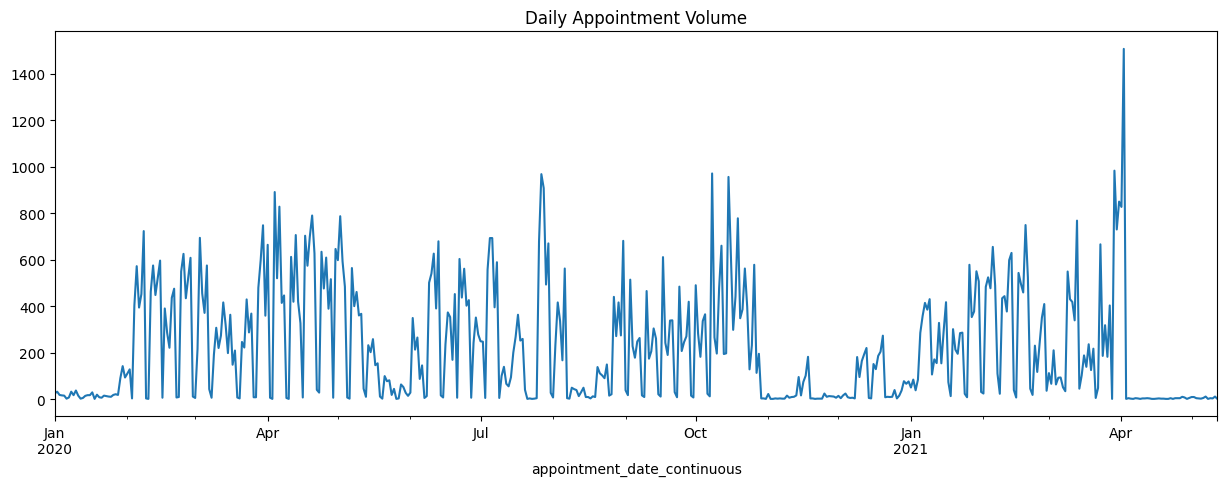

In [31]:
import matplotlib.pyplot as plt

daily['y'].plot(figsize=(15,5))

plt.title(
    'Daily Appointment Volume'
)

plt.show()

#Aggregate Daily Features
convert Appointment-level-data into daily level data

In [32]:
daily_features = df.resample('D').mean()

daily = daily.join(daily_features)

In [33]:
print(daily.head())

print(daily.shape)

                              y   no_show        age  under_12_years_old  \
appointment_date_continuous                                                
2020-01-01                   25  0.360000  11.520000            0.480000   
2020-01-02                   32  0.281250  14.328125            0.406250   
2020-01-03                   18  0.444444  13.388889            0.500000   
2020-01-04                   16  0.125000  17.437500            0.375000   
2020-01-05                   15  0.133333  13.833333            0.466667   

                             over_60_years_old  patient_needs_companion  \
appointment_date_continuous                                               
2020-01-01                            0.000000                 0.480000   
2020-01-02                            0.031250                 0.437500   
2020-01-03                            0.000000                 0.500000   
2020-01-04                            0.187500                 0.562500   
2020-01-05       

In [34]:
daily.isnull().sum().sort_values(
    ascending=False
).head(20)

y                          0
no_show                    0
age                        0
under_12_years_old         0
over_60_years_old          0
patient_needs_companion    0
average_temp_day           0
average_rain_day           0
max_temp_day               0
max_rain_day               0
rainy_day_before           0
storm_day_before           0
Hipertension               0
Diabetes                   0
Alcoholism                 0
Handcap                    0
Scholarship                0
SMS_received               0
place_encoded              0
specialty_enf              0
dtype: int64

Add Time Features (important for forecasting)


In [36]:
daily['day_of_week'] = daily.index.dayofweek
daily['month'] = daily.index.month
daily['week_of_year'] = (
    daily.index.isocalendar().week.astype(int)
)
daily['day_of_month'] = daily.index.day

In [37]:
daily[
    ['day_of_week',
     'month',
     'week_of_year',
     'day_of_month']
].head()

,day_of_week,month,week_of_year,day_of_month
appointment_date_continuous,,,,
2020-01-01,2,1,1,1
2020-01-02,3,1,1,2
2020-01-03,4,1,1,3
2020-01-04,5,1,1,4
2020-01-05,6,1,1,5


Lag Features:Need to provide Model demand of privious data 

Meaning:

lag_1 → yesterday appointments
lag_7 → last week same day
lag_14 → 2 weeks before

In [38]:
daily['lag_1'] = daily['y'].shift(1)
daily['lag_7'] = daily['y'].shift(7)
daily['lag_14'] = daily['y'].shift(14)

Rolling Mean Features

In [39]:
daily['rolling_mean_1'] = (
    daily['y']
    .rolling(1)
    .mean()
)

daily['rolling_mean_7'] = (
    daily['y']
    .rolling(7)
    .mean()
)

daily['rolling_mean_14'] = (
    daily['y']
    .rolling(14)
    .mean()
)

Beacause of Lag/rolling  first rows conatins NaN 

In [40]:
daily = daily.dropna()

In [41]:
print(
    daily[
        [
            'y',
            'rolling_mean_1',
            'rolling_mean_7',
            'rolling_mean_14'
        ]
    ].head()
)

                              y  rolling_mean_1  rolling_mean_7  \
appointment_date_continuous                                       
2020-01-15                   17            17.0       15.285714   
2020-01-16                   17            17.0       15.285714   
2020-01-17                   29            29.0       14.142857   
2020-01-18                    1             1.0       12.142857   
2020-01-19                   19            19.0       14.571429   

                             rolling_mean_14  
appointment_date_continuous                   
2020-01-15                         16.357143  
2020-01-16                         15.285714  
2020-01-17                         16.071429  
2020-01-18                         15.000000  
2020-01-19                         15.285714  


In [43]:
print(daily.shape)

daily.head()

(484, 47)


,y,no_show,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,...,day_of_week,month,week_of_year,day_of_month,lag_1,lag_7,lag_14,rolling_mean_1,rolling_mean_7,rolling_mean_14
appointment_date_continuous,,,,,,,,,,,,,,,,,,,,,
2020-01-15,17,0.235294,14.294118,0.352941,0.117647,0.470588,19.770000,0.022775,23.464706,0.106098,...,2,1,3,15,14.0,32.0,25.0,17.0,15.285714,16.357143
2020-01-16,17,0.235294,15.735294,0.352941,0.117647,0.529412,20.269412,0.092542,23.623529,0.584471,...,3,1,3,16,17.0,17.0,32.0,17.0,15.285714,15.285714
2020-01-17,29,0.482759,13.913793,0.517241,0.000000,0.551724,20.336207,0.095246,23.831034,0.674534,...,4,1,3,17,17.0,37.0,18.0,29.0,14.142857,16.071429
2020-01-18,1,1.000000,19.000000,0.000000,0.000000,0.000000,20.730000,0.122218,24.200000,0.993252,...,5,1,3,18,29.0,15.0,16.0,1.0,12.142857,15.000000
2020-01-19,19,0.368421,15.447368,0.315789,0.052632,0.368421,21.791579,0.078048,24.336842,0.473373,...,6,1,3,19,1.0,2.0,15.0,19.0,14.571429,15.285714


In [44]:
print(daily.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484 entries, 2020-01-15 to 2021-05-12
Freq: D
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   y                               484 non-null    int64  
 1   no_show                         484 non-null    float64
 2   age                             484 non-null    float64
 3   under_12_years_old              484 non-null    float64
 4   over_60_years_old               484 non-null    float64
 5   patient_needs_companion         484 non-null    float64
 6   average_temp_day                484 non-null    float64
 7   average_rain_day                484 non-null    float64
 8   max_temp_day                    484 non-null    float64
 9   max_rain_day                    484 non-null    float64
 10  rainy_day_before                484 non-null    float64
 11  storm_day_before                484 non-null    float64
 12  Hipertens

In [45]:
print(daily.dtypes)

y                                   int64
no_show                           float64
age                               float64
under_12_years_old                float64
over_60_years_old                 float64
patient_needs_companion           float64
average_temp_day                  float64
average_rain_day                  float64
max_temp_day                      float64
max_rain_day                      float64
rainy_day_before                  float64
storm_day_before                  float64
Hipertension                      float64
Diabetes                          float64
Alcoholism                        float64
Handcap                           float64
Scholarship                       float64
SMS_received                      float64
place_encoded                     float64
specialty_enf                     float64
specialty_occupational therapy    float64
specialty_pedagogo                float64
specialty_physiotherapy           float64
specialty_psychotherapy           

In [46]:
df.isnull().sum()

no_show                           0
age                               0
under_12_years_old                0
over_60_years_old                 0
patient_needs_companion           0
average_temp_day                  0
average_rain_day                  0
max_temp_day                      0
max_rain_day                      0
rainy_day_before                  0
storm_day_before                  0
Hipertension                      0
Diabetes                          0
Alcoholism                        0
Handcap                           0
Scholarship                       0
SMS_received                      0
place_encoded                     0
specialty_enf                     0
specialty_occupational therapy    0
specialty_pedagogo                0
specialty_physiotherapy           0
specialty_psychotherapy           0
specialty_sem especialidade       0
specialty_speech therapy          0
gender_M                          0
appointment_shift_morning         0
disability_motor            

In [52]:
daily.to_csv("../data/forecasting_data_WithFeature.csv")
print("data Save....")

data Save....


In [54]:
daily.to_pickle("../models/forecasting_data.pkl")

In [50]:
daily.columns

Index(['y', 'no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received', 'place_encoded', 'specialty_enf',
       'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm', 'day_of_week', 'month', 'week_of_year',
       'day_of_month', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_1',
       'rolling_mean_7', 'rolling_mean_14'],
   

<Axes: xlabel='appointment_date_continuous'>

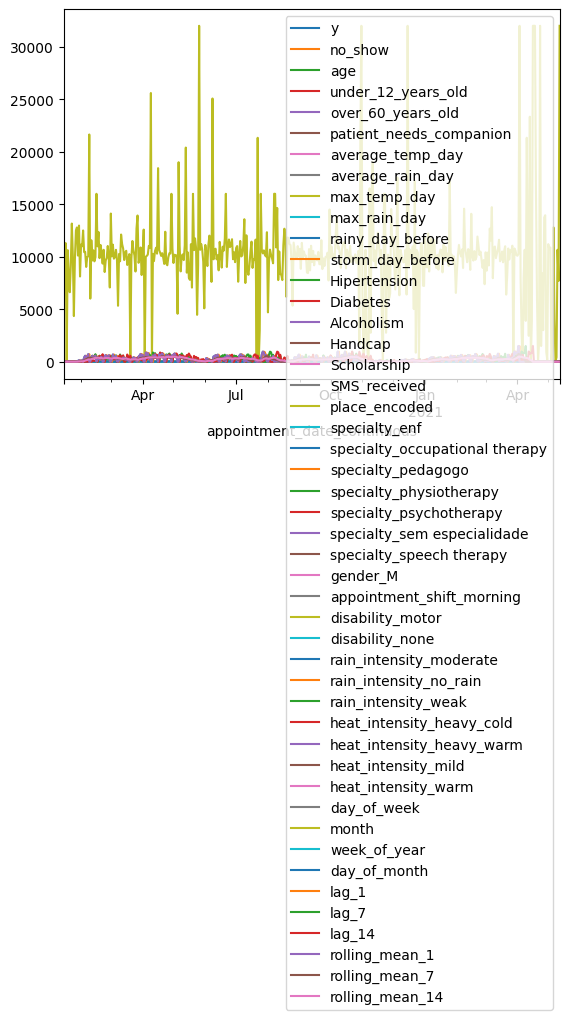

In [51]:
daily.isnull().sum()
daily.plot()

In [55]:
daily.shape

(484, 47)